# MeS product distortion and correlations

Read the persisted thermodynamics/kinetics summary, generate isolated diene distortion single-point inputs, then collect completed calculations and draw correlations. The distortion geometry comes from the selected MeS product; it is not a TS distortion.

Original notebooks and all saved outputs are preserved in `notebooks/archive/discovery_before_split_20260928/`. This reorganized notebook has not been executed.


In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

start = Path.cwd().resolve()
REPO_ROOT = next((p for p in (start, *start.parents)
                  if (p / "Code" / "model_train.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter within the CycloAddGenerator repository.")
for folder in (REPO_ROOT, REPO_ROOT / "notebooks",
               REPO_ROOT / "notebooks/04_discovery", REPO_ROOT / "notebooks/05_mechanism"):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))
os.chdir(REPO_ROOT)


In [2]:
from _mes_common import *
from _workflow_paths import require_file
display(pd.DataFrame({"path": [str(INPUT_CSV), str(OUTPUT_DIR), str(ALL_SMILES_CSV)],
                      "exists": [INPUT_CSV.is_file(), OUTPUT_DIR.is_dir(), ALL_SMILES_CSV.is_file()]}))


c:\Users\Jackie\anaconda3\envs\main_py3_12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,path,exists
0,D:\OneDrive_all\OneDrive\Work\work_part\9.Cycl...,False
1,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,True
2,E:\work\Secondary_Selection\Diene_Ene_Smiles\a...,True


## Generate distortion inputs

In [3]:
# Generate product_distort/*.gjf for selected lowest-deltaG MeS products.
RUN_MES_DISTORTION_INPUTS = True

if RUN_MES_DISTORTION_INPUTS:
    mes_distort_manifest, mes_distort_failed = generate_mes_selected_diene_distortion_inputs(
        overwrite=False,
    )
    display(mes_distort_manifest.head())


100%|██████████| 24/24 [00:00<00:00, 47.94it/s]

Wrote/checked 21 MeS distorted-diene inputs
Failed distortion inputs: 3


,product_log_path,distort_gjf_path,kept_atoms,removed_atoms,diene_charge,title
0,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,10,10 11 12 13 14,0,3 5 1 0 10 1
1,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,10,10 11 12 13 14,0,3 6 0 1 10 1
2,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,14,14 15 16 17 18,0,1 6 0 1 14 1
3,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,12,12 13 14 15 16,0,3 5 1 0 12 -1
4,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,17,17 18 19 20 21,0,0 3 0 1 17 1


## Correlation of MeS addition energetics with \(\Delta E_{\mathrm{dist-4\pi}}\) and \(f_{4\pi}\)

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 2049.17it/s]


,$\Delta E_{\mathrm{dist-4\pi}}$,$f_{4\pi}$,"$\Delta G_{\mathrm{rxn,MeS}}$",$\Delta G^{\ddagger}_{\mathrm{MeS}}$,$\Delta G^{\ddagger}_{\mathrm{DA}}$
$\Delta E_{\mathrm{dist-4\pi}}$,1.000000,0.442798,0.141646,0.981580,0.328458
$f_{4\pi}$,0.442798,1.000000,-0.327202,0.899243,-0.363195
"$\Delta G_{\mathrm{rxn,MeS}}$",0.141646,-0.327202,1.000000,0.977915,0.579711
$\Delta G^{\ddagger}_{\mathrm{MeS}}$,0.981580,0.899243,0.977915,1.000000,0.968863
$\Delta G^{\ddagger}_{\mathrm{DA}}$,0.328458,-0.363195,0.579711,0.968863,1.000000


,$\Delta E_{\mathrm{dist-4\pi}}$,$f_{4\pi}$,"$\Delta G_{\mathrm{rxn,MeS}}$",$\Delta G^{\ddagger}_{\mathrm{MeS}}$,$\Delta G^{\ddagger}_{\mathrm{DA}}$
$\Delta E_{\mathrm{dist-4\pi}}$,1.000000,0.591304,0.148696,0.9,0.086957
$f_{4\pi}$,0.591304,1.000000,-0.072174,0.8,-0.346957
"$\Delta G_{\mathrm{rxn,MeS}}$",0.148696,-0.072174,1.000000,1.0,0.473043
$\Delta G^{\ddagger}_{\mathrm{MeS}}$,0.900000,0.800000,1.000000,1.0,0.900000
$\Delta G^{\ddagger}_{\mathrm{DA}}$,0.086957,-0.346957,0.473043,0.9,1.000000


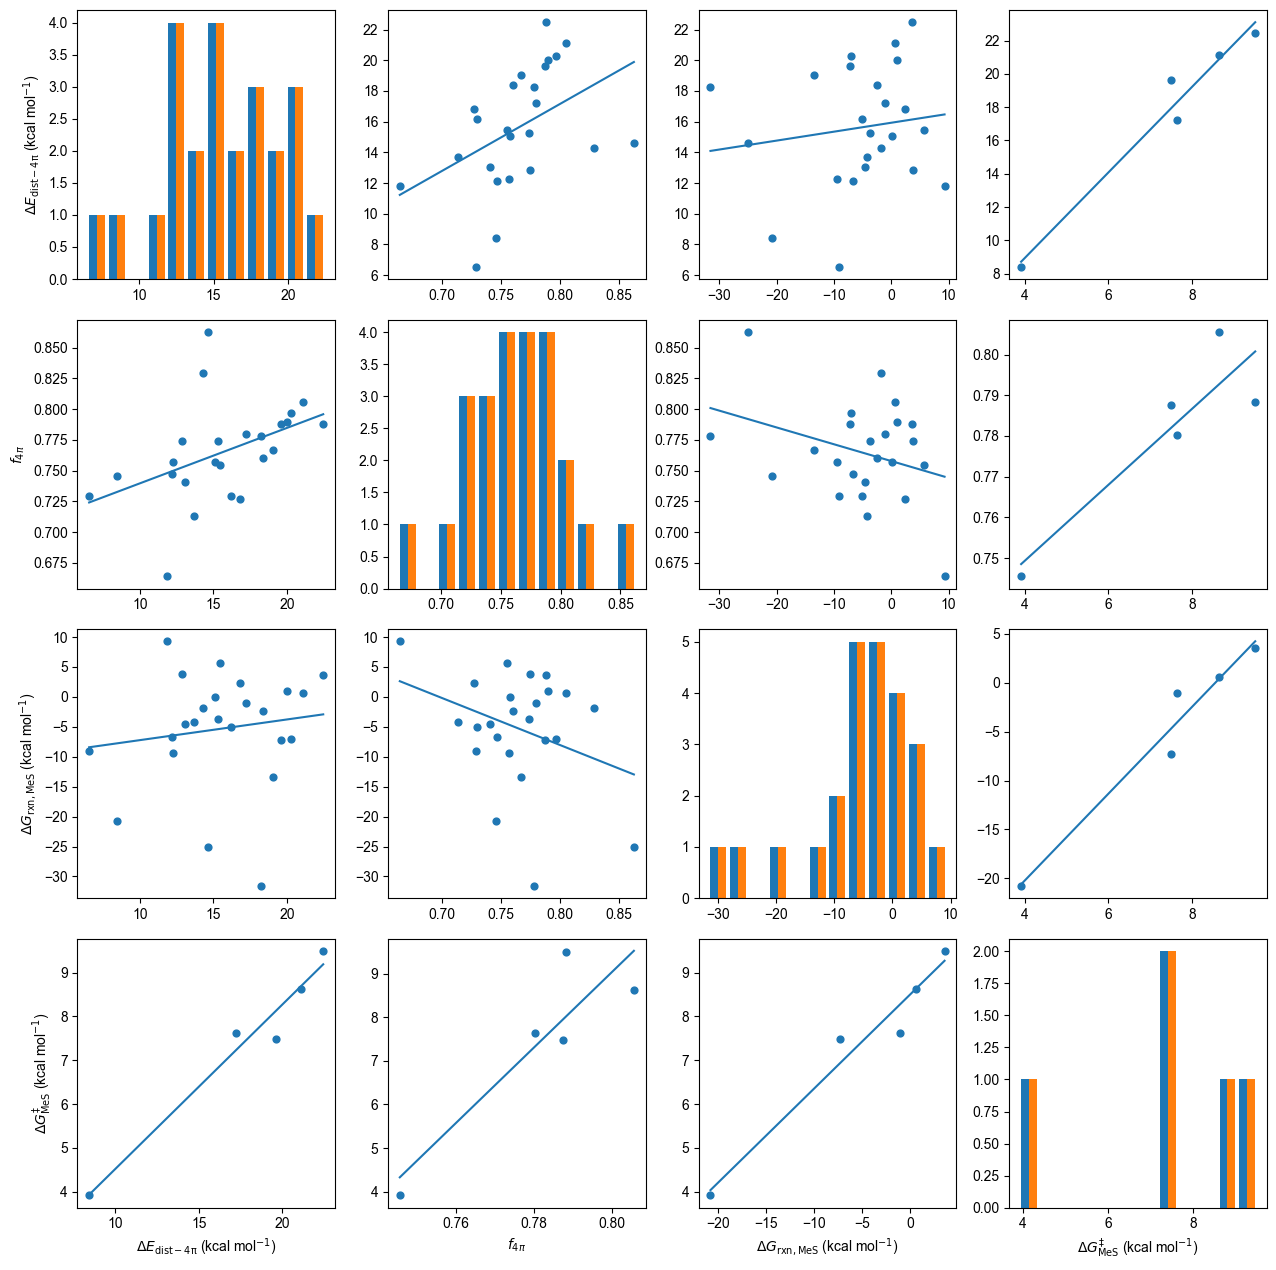

,diene_index,product_stem_thermo,MeS_deltaG,product_log_path,product_eng_log_path,Diene_Distort,Ene_Distort,Interaction,deltaGa(Solvent),Diene,...,ts_stem,product_stem_kinetic,MeS_deltaGa,ts_success_log_path,ts_success_eng_log_path,product_cs_distance,forward_distance,reverse_distance,distort_log_path,Distortion_energy
0,5944,MAA_MeS_D05944_R000000_a0_up,-1.779329,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,14.286074,2.939910,36.850016,11.028026,c1nncnn1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,NaN
1,13033,MAA_MeS_D13033_R000005_b5_up,-6.724902,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,12.150390,4.117871,28.299692,18.847656,N#CC(=N)C(=N)C#N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,NaN
2,13337,MAA_MeS_D13337_R000006_a3_up,-25.017955,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,14.636281,2.326035,38.345766,13.492999,O=C(O)/N=N/C(=O)O,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,NaN
3,13341,MAA_MeS_D13341_R000007_b4_down,3.789127,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,12.851400,3.742517,24.433468,19.871978,O=C(O)C1=CCC=C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,NaN
4,13744,MAA_MeS_D13744_R000011_a1_up,-9.437717,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,12.230945,3.921624,29.798152,21.076063,C/N=C(\C#N)C(=O)C(=O)O,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E:\work\Secondary_Selection\7_MAAtest_MeS_atta...,NaN


In [4]:
# Collect product distortion energies after the Gaussian single-point calculations.
RUN_MES_DISTORTION_COLLECT = True

if RUN_MES_DISTORTION_COLLECT:
    mes_final_df = collect_mes_diene_distortion_energies()
    mes_pearson_corr, mes_spearman_corr = plot_mes_correlation_panel(mes_final_df)
    display(mes_final_df.head())


In [5]:
mes_final_df.dropna(subset=['MeS_deltaGa'])['Diene_Distort'].to_numpy() / (mes_final_df.dropna(subset=['MeS_deltaGa'])['Diene_Distort'].to_numpy() + mes_final_df.dropna(subset=['MeS_deltaGa'])['Ene_Distort'].to_numpy())

array([0.78829816, 0.80559277, 0.78750361, 0.78012002, 0.74553303])